# Two-epoch coalescent inference with BFFG

Backward-Filtering Forward-Guiding (BFFG) inference of a two-epoch coalescent model, using sparse single-mutation observations (singletons, doubletons, ...).

**Model.** Block coalescent with $n$ samples and a piecewise-constant pairwise coalescence rate:
$$
\theta(t) = \begin{cases} \theta_1, & t < \tau \\ \theta_2, & t \ge \tau \end{cases}
$$
with epoch boundary $\tau$ assumed known. The pairwise rate is multiplied by $\binom{k}{2}$ when $k$ lineages remain.

**Observation model.** At each locus we observe one mutation type $j \in \{1,\dots,n-1\}$ (singleton/doubleton/...). The probability of observing type $j$ given the genealogy $g$ is proportional to the total branch length of type-$j$ lineages, $B_j(g)$. We use the **joint probability graph** to compute these probabilities and to sample paths conditional on the observed mutation type.

**BFFG.** Paths are sampled under a homogeneous proposal with constant rate $\theta_0$ via `sample_path_conditioned`. The importance weight corrects to the time-inhomogeneous target by re-weighting using the density of coalescence events in each epoch:
$$
\log w = \sum_k \bigl[\log \theta(t_k) - \log \theta_0\bigr]
       - \sum_{\text{epoch }e} (\theta_e - \theta_0)\, P_e
$$
where $t_k$ are coalescence times and $P_e = \sum_{\text{sojourns in }e} \binom{k_s}{2}\,\Delta t_s$ is the pair-time spent in epoch $e$.

**Inference.** MCMC over $(\theta_1, \theta_2)$ in two ways:

1. A **manual, transparent** BFFG log-likelihood plumbed into `MCMC(log_prob_fn=...)`. Easy to introspect for diagnostics — used through section 9.
2. The **package's `bffg_log_prob(..., return_model=True)`** plumbed into `MCMC(model=..., likelihood_correction=...)`, which uses the FFI-cached sojourn-time computation for the model term and the exit-rate-ratio importance weight for the correction. Section 10.

In [1]:
from phasic import (
    Graph, MCMC, GaussPrior, with_ipv,
    StateIndexer, Property,
    path_to_rewards, path_exit_rates,
    importance_log_weight_from_rates, importance_weighted_log_likelihood,
)

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax.scipy.special import logsumexp

from vscodenb import set_vscode_theme
set_vscode_theme()

np.random.seed(42)
rng = np.random.default_rng(42)

## 1. Build the coalescent graph

State vector: $(b_1, b_2, \dots, b_n)$ where $b_j$ is the number of blocks of size $j$. A coalescence between a size-$i$ block and a size-$j$ block produces a size-$(i+j)$ block; the rate is the pair count times the per-pair coalescence rate $\theta_1$.

We expose $\theta_1$ as a single parameterized coefficient — the resulting graph has constant rate. Time-inhomogeneity is added later through the BFFG importance weight.

In [2]:
from itertools import combinations_with_replacement

N_SAMPLES = 4   # singletons, doubletons, tripletons → 3 mutation types

# Build the indexer first so the initial state vector can be constructed via props_to_index.
indexer = StateIndexer(
    lineages=[Property('ton', min_value=1, max_value=N_SAMPLES)]
)
ipv = [0] * indexer.state_length
ipv[indexer.props_to_index(ton=1)] = N_SAMPLES  # start with N_SAMPLES singletons

@with_ipv(ipv)
def coal_callback(state, indexer=None):
    transitions = []
    for i, j in combinations_with_replacement(range(state.size), 2):
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        new[min(i + j + 1, state.size - 1)] += 1
        pair_count = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, [pair_count]])
    return transitions

g_cont = Graph(coal_callback, indexer=indexer)
#g_cont.update_weights([1.0])  # placeholder; proposal rate set below
print(f"Continuous coalescent graph: {g_cont.vertices_length()} vertices, "
      f"state length {g_cont.state_length()}")

Continuous coalescent graph: 6 vertices, state length 4


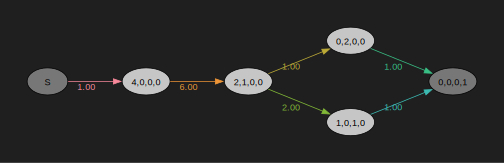

In [3]:
g_cont.update_weights([1])
g_cont.plot()

In [ ]:
# What you have implemented is not quite what I had in mind. The model to sample from should be an epoch model produced like this:

indexer = StateIndexer(
    lineages=[Property('descendants', min_value=1, max_value=N_SAMPLES)],
)
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1)] = N_SAMPLES  # start with N_SAMPLES singletons

@with_ipv(ipv)
def coal_callback(state, indexer=None):
    transitions = []
    for i, j in combinations_with_replacement(range(indexer.lineages.state_length), 2):
        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        new[min(i + j + 1, state.size - 1)] += 1
        pair_count = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, [pair_count]])
    return transitions

EPOCH_BOUNDARY = 0.5
TRUE_THETA1 = 2.0
TRUE_THETA2 = 0.5
MUTATION_RATE = 0.01
REWARD_LIMIT = 5

g_cont = Graph(coal_callback, indexer=indexer)  
g_epochs = g_cont.add_epoch(time=EPOCH_BOUNDARY)
g_epochs.update_weights([TRUE_THETA1, TRUE_THETA2, 1]) # last coefficient should be fixed to one to preserve epoch transition rates
jg_cont = g_epochs.joint_prob_graph(
    indexer,
    mutation_rate=MUTATION_RATE,
    reward_limit=REWARD_LIMIT,
)

StateIndexer(lineages=[descendants:1-4])
StateIndexer(lineages=[descendants:1-4], epoch=slot)
StateIndexer(lineages=[descendants:1-4], lineages_descendants=[lineages_descendants:1-4], epoch=slot)
Graph has too many nodes (1024). Please set max_nodes to a higher value.


In [7]:
# What you have implemented is not quite what I had in mind. The model to sample from should be an epoch model produced like this:

# Build the indexer first so the initial state vector can be constructed via props_to_index.
indexer = StateIndexer(
    lineages=[Property('descendants', min_value=1, max_value=N_SAMPLES)],
)
ipv = [0] * indexer.state_length
ipv[indexer.lineages.props_to_index(descendants=1)] = N_SAMPLES  # start with N_SAMPLES singletons

@with_ipv(ipv)
def coal_callback(state, indexer=None):
    transitions = []
    for i, j in combinations_with_replacement(range(indexer.lineages.state_length), 2):

        # here the indexer is not needed in this case but included for generality of the pattern
        props_i = indexer.lineages.index_to_props(i)
        desc_i = props_i.descendants
        props_j = indexer.lineages.index_to_props(j)
        desc_j = props_j.descendants

        same = int(i == j)
        if same and state[i] < 2:
            continue
        if not same and (state[i] < 1 or state[j] < 1):
            continue
        new = state.copy()
        new[i] -= 1
        new[j] -= 1
        new[min(i + j + 1, state.size - 1)] += 1
        pair_count = state[i] * (state[j] - same) / (1 + same)
        transitions.append([new, [pair_count]])
    return transitions

EPOCH_BOUNDARY = 0.5
TRUE_THETA1 = 2.0
TRUE_THETA2 = 0.5
REWARD_LIMIT = 0.01

g_cont = Graph(coal_callback, indexer=indexer)
g_epochs = g_cont.add_epoch(time=EPOCH_BOUNDARY)
g_epochs.update_weights([TRUE_THETA1, TRUE_THETA2, 1]) # last coefficient should be fixed to one to preserve epoch transition rates

jg_cont = g_epochs.joint_prob_graph(
    indexer,
    mutation_rate=0.01,
    reward_limit=8,
)

jg_cont.plot()

Graph has too many nodes (3262). Please set max_nodes to a higher value.


In [48]:
indexer.state_length

4

## 2. Build the joint probability graph

The joint probability graph extends the state vector with a per-mutation-type counter and adds mutation-rate edges. The terminal vertices represent the observation "the mutation that occurred was on a type-$j$ branch". The probabilities of these terminals — given $\theta$ and the mutation rate $\mu$ — give the categorical observation likelihood.

In [3]:
MUTATION_RATE = 1.0

# tot_reward_limit=1 → exactly one mutation per locus (the sparse single-mutation observation).
# The same indexer is reused: joint_prob_graph extends it internally with reward properties.
jg_cont = g_cont.joint_prob_graph(
    indexer,
    mutation_rate=MUTATION_RATE,
    tot_reward_limit=1,
)
jg_cont.is_discrete = False  # for path sampling we want continuous time

jg_disc = g_cont.joint_prob_graph(
    indexer,
    mutation_rate=MUTATION_RATE,
    tot_reward_limit=1,
)
# jg_disc keeps is_discrete=True (set by joint_prob_graph) for joint_prob_table()

print(f"Joint graph: {jg_cont.vertices_length()} vertices, "
      f"state length {jg_cont.state_length()}, "
      f"param_length {jg_cont.param_length()}")

Joint graph: 20 vertices, state length 8, param_length 2


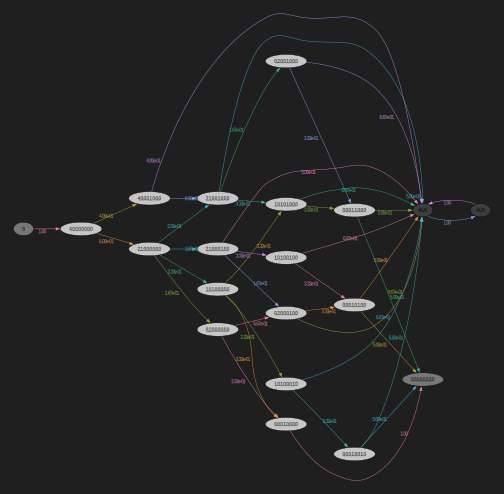

In [24]:
jg_cont.plot()

In [4]:
# Proposal parameters
THETA_0 = 1.0                          # constant proposal rate
theta_proposal = np.array([THETA_0, MUTATION_RATE])

jg_disc.update_weights(theta_proposal.tolist())
jpt = jg_disc.joint_prob_table()
print(jpt)

# Each row of joint_prob_table corresponds to a t-vertex (SFS bin). The columns
# before 'prob' encode the reward state (counts of each mutation type).
# Build a map: mutation_type (1..n-1) → t-vertex index.
terminal_indices = list(jpt.index)
term_state_cols = jpt.columns[:-1]
print("Reward state columns:", list(term_state_cols))

mut_type_to_terminal = {}
for tv in terminal_indices:
    state_row = jpt.loc[tv, term_state_cols].to_numpy(dtype=int)
    if state_row.sum() == 1:
        # column position of the 1 → block size of the mutated branch
        j = int(np.argmax(state_row)) + 1
        mut_type_to_terminal[j] = int(tv)
print("Mutation type → t-vertex index:", mut_type_to_terminal)

# We also need to map from path['vertex_indices'][-2] (the last non-absorbing vertex) back
# to the t-vertex set. Each t-vertex either IS the penultimate path vertex or the path
# went absorbing→absorbing — we just need the set of valid t-vertices for fast lookup.
valid_t_vertices = set(terminal_indices)

                ton_1  ton_2  ton_3  ton_4      prob
t_vertex_index                                      
8                   0      0      0      0  0.100000
14                  0      1      0      0  0.038889
15                  1      0      0      0  0.095556
16                  0      0      1      0  0.022222
Reward state columns: ['ton_1', 'ton_2', 'ton_3', 'ton_4']
Mutation type → t-vertex index: {2: 14, 1: 15, 3: 16}


## 3. Define the time-inhomogeneous target

Two-epoch piecewise-constant rate with hard switch at `EPOCH_BOUNDARY`. `theta_target_fn(theta_mcmc, t)` returns the per-pair rate at time $t$ — this is the function BFFG will use to re-weight sampled paths.

In [5]:
EPOCH_BOUNDARY = 0.5
TRUE_THETA1 = 2.0   # epoch 1: faster coalescence (smaller Ne)
TRUE_THETA2 = 0.5   # epoch 2: slower coalescence (larger Ne)
true_theta = np.array([TRUE_THETA1, TRUE_THETA2])

def theta_target_fn(theta_mcmc, t):
    # theta_mcmc = [theta1, theta2]; returns scalar rate at time t
    return jnp.where(t < EPOCH_BOUNDARY, theta_mcmc[0], theta_mcmc[1])

def theta_target_np(theta_np, t):
    return theta_np[0] if t < EPOCH_BOUNDARY else theta_np[1]

## 4. Importance weight for guided proposal paths

`Graph.sample_path_conditioned([t_v])` produces a **guided sequence proposal**: at each transient vertex it samples the next edge with probability $\propto w_e \cdot h(\mathrm{child}_e)$ where $h = $ `backward_probabilities([t_v])`. Critically, on a `joint_prob_graph` the stored edge weights are **normalized** (the graph is a discrete-time Markov chain, `was_dph=True`), so the `entry_times` returned by the C sampler come from $\mathrm{Exp}(1)$ and are not physical sojourn times.

For inference with a time-inhomogeneous target rate $\theta(t)$ we therefore **resample physical sojourn times** ourselves at each transient vertex, drawing $\Delta t \sim \mathrm{Exp}(R_v^{\mathrm{prop}})$ where $R_v^{\mathrm{prop}} = \theta_0 S_v^\theta + \mu S_v^\mu$ with $S_v^\theta = \sum_e c_e^\theta = \binom{k_{\mathrm{lin}}}{2}$ and $S_v^\mu = \sum_e c_e^\mu$. The combined proposal density (over sequence and physical times) is

$$
p_{\mathrm{prop}}(\pi) \;=\; \prod_v \, w_e^{\mathrm{prop}}\, e^{-R_v^{\mathrm{prop}}\,\Delta t_v}\, \frac{h(\mathrm{child}_e)}{\sum_{e'} w_{e'}^{\mathrm{prop}}\,h(\mathrm{child}_{e'})}.
$$

The target unconditional density on the same graph (with $\theta$ replaced by $\theta(t)$, $\mu$ unchanged) is

$$
p_{\mathrm{tgt}}(\pi) \;=\; \prod_v \, w_e^{\mathrm{tgt}}(t_{k+1})\, \exp\!\left(-\!\int_{t_k}^{t_{k+1}}\! R_v^{\mathrm{tgt}}(u)\,du\right).
$$

Per transient step,

$$
\log w_{\mathrm{step}} \;=\; \log w_e^{\mathrm{tgt}}(t_{k+1}) - S_{\mathrm{int}}
- \log w_e^{\mathrm{prop}} + R_v^{\mathrm{prop}}\,\Delta t_v
- \log h(\mathrm{child}_e) + \log\!\sum_{e'} w_{e'}^{\mathrm{prop}}\,h(\mathrm{child}_{e'})
$$

with target survival integral $S_{\mathrm{int}} = (\sum_e \theta_e \Delta t^{(e)})\,S_v^\theta + \mu S_v^\mu \Delta t$.

**Identity check.** When $\theta(t) \equiv \theta_0$, the per-step contribution simplifies via the backward equation $\sum_e w_e\,h(\mathrm{child}_e) = R_v\,h(v)$ to $\log h(v_k) - \log h(\mathrm{child}_e)$, telescoping to $\log h(v_{\mathrm{first}})$ — a path-independent constant. So $\mathrm{var}(\log w) = 0$ at identity, and $E[\exp(\log w)] = h_{\mathrm{tgt}}(v_0)$ in general.

The pseudo-marginal estimator is $\log P(s\mid\theta_{\mathrm{target}}) \approx \log E_{\mathrm{prop}}[\exp(\log w)]$.

In [6]:
from scipy.special import logsumexp as scipy_logsumexp


def theta_integral(theta_target_np_fn, theta_arg, t_in, t_out, epoch_boundary):
    """Integrate theta(t) over [t_in, t_out] for piecewise-constant theta with one boundary."""
    if t_out <= epoch_boundary:
        return theta_target_np_fn(theta_arg, t_in) * (t_out - t_in)
    if t_in >= epoch_boundary:
        return theta_target_np_fn(theta_arg, t_in) * (t_out - t_in)
    th1 = theta_target_np_fn(theta_arg, t_in)
    th2 = theta_target_np_fn(theta_arg, t_out)
    return th1 * (epoch_boundary - t_in) + th2 * (t_out - epoch_boundary)


def vertex_edge_data(jg, n_params=2):
    """Cache per-vertex parameterized-edge tables for the joint graph.

    Returns a dict {vertex_idx: (children_array, c_theta, c_mu)} for transient vertices.
    Pads ragged edge_states (the start vertex's IPV edges have length-1 edge_state) to
    n_params with zeros in the missing slots.
    """
    out = {}
    for vi, v in enumerate(jg.vertices()):
        if v.edges_length() == 0:
            continue
        edges = v.parameterized_edges()
        if not edges:
            continue
        rows = []
        for e in edges:
            es = list(e.edge_state(n_params))
            if len(es) < n_params:
                es = es + [0.0] * (n_params - len(es))
            rows.append(es[:n_params])
        coeffs = np.array(rows, dtype=float)
        if coeffs.ndim == 1:
            coeffs = coeffs.reshape(1, -1)
        children = np.array([e.to().index() for e in edges], dtype=int)
        out[vi] = (children, coeffs[:, 0].copy(), coeffs[:, 1].copy())
    return out


def log_iw_corrected(jg, path, theta_target_np_fn, theta_arg, theta_0, mu,
                     epoch_boundary, h, t_vertex, edge_cache=None,
                     rng=None, n_params=2):
    """Importance weight for a guided sequence path from sample_path_conditioned([t_vertex]).

    The joint_prob_graph is a normalized DTMC, so the C sampler's entry_times are not
    physical sojourn times. We resample physical sojourn Δt ∼ Exp(R_v^prop) at each
    transient vertex using the supplied rng, then evaluate the IS weight against the
    *unconditional CTMC at the time-varying target rate*.

    Per-step contribution to log_w = log p_tgt − log p_prop:

        log w_step = log w_e^tgt(t_jump) − S_int            (target step density)
                   − log R_v^prop + R_v^prop·Δt              (cancel proposal sojourn density)
                   − log w_e^prop                            (cancel proposal jump weight)
                   − log h(child) + log Σ_e w_e^prop h(child_e)   (undo guided edge prob)

    Identity check: target = proposal collapses every step to log h(v_k) − log h(child_e),
    which telescopes across the path to log h(v_first) (= log h(v_0) since v_0 → v_first
    is deterministic). So var(log_w) = 0 at identity, and E[exp(log_w)] = h_target(v_0).

    Returned log_w satisfies E_{p_prop}[exp(log_w)] = h_target(v_0) = P_target(reach t_v).
    The pseudo-marginal estimator is therefore log P(s|θ_target) ≈ log mean(exp(log_w)).
    """
    if rng is None:
        rng = np.random
    if edge_cache is None:
        edge_cache = vertex_edge_data(jg, n_params=n_params)

    indices = path['vertex_indices']

    log_w = 0.0
    cumulative_t = 0.0
    for step in range(1, len(indices) - 1):
        v_idx = int(indices[step])
        if v_idx == t_vertex:
            break
        if v_idx not in edge_cache:
            break

        children, c_theta, c_mu = edge_cache[v_idx]
        h_child = h[children]

        w_prop = theta_0 * c_theta + mu * c_mu
        R_prop = w_prop.sum()
        if R_prop <= 0:
            return -np.inf
        S_theta = c_theta.sum()
        S_mu = c_mu.sum()

        valid = (h_child > 0) & (w_prop > 0)
        log_Z_prop = scipy_logsumexp(np.log(w_prop[valid]) + np.log(h_child[valid]))

        # taken edge: child = indices[step + 1]
        next_v = int(indices[step + 1])
        e_idx_arr = np.where(children == next_v)[0]
        if e_idx_arr.size == 0:
            break
        e_idx = int(e_idx_arr[0])

        # Sample physical sojourn from Exp(R_prop)
        u = rng.uniform()
        dt = -np.log(u + 1e-30) / R_prop

        t_in = cumulative_t
        t_out = cumulative_t + dt
        cumulative_t = t_out

        theta_int = theta_integral(theta_target_np_fn, theta_arg, t_in, t_out, epoch_boundary)
        S_int = theta_int * S_theta + mu * S_mu * dt

        theta_at_jump = theta_target_np_fn(theta_arg, t_out)
        w_tgt_e = theta_at_jump * c_theta[e_idx] + mu * c_mu[e_idx]
        if w_tgt_e <= 0 or w_prop[e_idx] <= 0 or h_child[e_idx] <= 0:
            return -np.inf

        log_w += (
            np.log(w_tgt_e) - S_int                                 # target log density of step
            - np.log(R_prop) + R_prop * dt                          # cancel proposal sojourn density
            - np.log(w_prop[e_idx])                                 # cancel proposal jump weight
            - np.log(h_child[e_idx]) + log_Z_prop                   # undo guided edge prob
        )
    return log_w

In [7]:
# --- Sanity checks for log_iw_corrected ---

jg_cont.update_weights(theta_proposal.tolist())
v_start = jg_cont.starting_vertex().index()
edge_cache_cont = vertex_edge_data(jg_cont, n_params=2)
test_rng = np.random.default_rng(1)

# Test 1 (identity). With target = proposal, log_w must be a path-independent constant
# equal to log h(v_first), and E[exp(log_w)] = h_proposal(v_start).
target_v = mut_type_to_terminal[1]   # singleton t-vertex
h_tv_prop = jg_cont.backward_probabilities([target_v])

def theta_target_const(theta_arg, t):
    return theta_arg

log_ws_id = []
for _ in range(300):
    p = jg_cont.sample_path_conditioned([target_v])
    log_ws_id.append(log_iw_corrected(
        jg_cont, p, theta_target_const, THETA_0, THETA_0, MUTATION_RATE,
        EPOCH_BOUNDARY, h_tv_prop, target_v, edge_cache=edge_cache_cont, rng=test_rng))
log_ws_id = np.array(log_ws_id)
print("Identity test (target = proposal):")
print(f"  var(log_w) = {np.var(log_ws_id):.3e}    (must be ≈ 0)")
print(f"  mean(log_w) = {np.mean(log_ws_id):.6f}    expected log h(v0) = {np.log(h_tv_prop[v_start]):.6f}")
print(f"  E[exp(log_w)] = {np.mean(np.exp(log_ws_id)):.6f}    h_proposal(v0) = {h_tv_prop[v_start]:.6f}")

# Test 2 (homogeneous perturbation). With target = (1+ε)·θ_0 (homogeneous),
# the exact reach probability under target is read from a re-built joint graph.
EPS = 0.05
jg_test = g_cont.joint_prob_graph(indexer, mutation_rate=MUTATION_RATE, tot_reward_limit=1)
jg_test.is_discrete = False
jg_test.update_weights([THETA_0 * (1 + EPS), MUTATION_RATE])
h_tgt_test = jg_test.backward_probabilities([target_v])
expected_h_tgt = h_tgt_test[v_start]
jg_cont.update_weights(theta_proposal.tolist())

print(f"\nPerturbation test (target = θ_0·(1+{EPS}) homogeneous):")
print(f"  expected E[exp(log_w)] = h_target(v0) = {expected_h_tgt:.6f}")

log_ws_pert = []
N_TEST = 5000
for _ in range(N_TEST):
    p = jg_cont.sample_path_conditioned([target_v])
    log_ws_pert.append(log_iw_corrected(
        jg_cont, p, theta_target_const, THETA_0 * (1 + EPS), THETA_0, MUTATION_RATE,
        EPOCH_BOUNDARY, h_tv_prop, target_v, edge_cache=edge_cache_cont, rng=test_rng))
log_ws_pert = np.array(log_ws_pert)
m = log_ws_pert.max()
empirical = np.mean(np.exp(log_ws_pert - m)) * np.exp(m)
se = np.std(np.exp(log_ws_pert - m)) * np.exp(m) / np.sqrt(N_TEST)
print(f"  empirical = {empirical:.6f} ± {se:.6f}")
print(f"  agreement: {abs(empirical - expected_h_tgt) / se:.2f} SE")

Identity test (target = proposal):
  var(log_w) = 1.834e-31    (must be ≈ 0)
  mean(log_w) = -2.348047    expected log h(v0) = -2.348047
  E[exp(log_w)] = 0.095556    h_proposal(v0) = 0.095556

Perturbation test (target = θ_0·(1+0.05) homogeneous):
  expected E[exp(log_w)] = h_target(v0) = 0.100532
  empirical = 0.100492 ± 0.000070
  agreement: 0.58 SE


## 5. Simulate observations under the true two-epoch model

We simulate sparse single-mutation observations under the **true** time-inhomogeneous model by importance-weighted rejection sampling: propose a path under the homogeneous proposal, accept with probability $\min(1, w/M)$ where $M$ is a (rough) bound on $w$. Each accepted path's terminal vertex tells us which SFS bin the mutation fell into.

In [8]:
def path_terminal_t_vertex(path, valid_t_vertices):
    """Return the t-vertex (SFS bin) the path landed on, or None if it went to trash."""
    indices = path['vertex_indices']
    for k in range(len(indices) - 1, -1, -1):
        v = int(indices[k])
        if v in valid_t_vertices:
            return v
    return None


def find_trash_vertices(jg):
    """Identify the trash_vertex and trash_loop_vertex pair of the joint graph.

    Both have all-zero state, edges_length() > 0, and form a 2-cycle. The starting
    vertex also has all-zero state but we exclude it.
    """
    trash = set()
    states = jg.states()
    start = jg.starting_vertex().index()
    for vi, v in enumerate(jg.vertices()):
        if vi == start or v.edges_length() == 0:
            continue
        if int(states[vi].sum()) == 0:
            trash.add(vi)
    return trash


# Pre-compute: edge cache, h(v) for each candidate t-vertex, trash vertices.
jg_cont.update_weights(theta_proposal.tolist())
edge_cache_cont = vertex_edge_data(jg_cont, n_params=2)
h_per_target = {tv: jg_cont.backward_probabilities([tv]) for tv in valid_t_vertices}
trash_vertices = find_trash_vertices(jg_cont)
print("Trash vertex indices:", trash_vertices)


def theta_target_pcw(theta_arg, t):
    """Piecewise-constant theta(t) for the two-epoch target."""
    return theta_arg[0] if t < EPOCH_BOUNDARY else theta_arg[1]


def gillespie_inhom_one(edge_cache, start_idx, theta_target_np_fn, theta_arg,
                        mu, epoch_boundary, rng, valid_t_vertices, trash_vertices,
                        max_steps=200):
    """Forward-simulate one path on the joint graph under the time-inhomogeneous
    target. Crosses the epoch boundary by truncating the proposed sojourn.

    Stops when (a) hits absorbing (no edges), (b) enters the trash loop, or
    (c) exceeds max_steps. Returns the last visited t-vertex (or None if no
    t-vertex was ever reached).
    """
    v = start_idx
    t = 0.0
    last_tv = None
    for _ in range(max_steps):
        if v in valid_t_vertices:
            last_tv = v
        if v not in edge_cache:
            break
        if v in trash_vertices:
            break  # path is now wandering in trash; whatever t-vertex we saw is the answer
        children, c_theta, c_mu = edge_cache[v]
        theta_t = theta_target_np_fn(theta_arg, t)
        rates = theta_t * c_theta + mu * c_mu
        total = rates.sum()
        if total <= 0:
            break
        u = rng.uniform()
        dt = -np.log(max(u, 1e-30)) / total
        if t < epoch_boundary and t + dt > epoch_boundary:
            t = epoch_boundary
            continue
        t = t + dt
        u2 = rng.uniform()
        cum = 0.0
        idx = len(children) - 1
        for j in range(len(children)):
            cum += rates[j] / total
            if u2 < cum:
                idx = j
                break
        v = int(children[idx])
    return last_tv


def simulate_observation(theta_target, mu, epoch_boundary, start_idx, edge_cache,
                         valid_t_vertices, trash_vertices, rng, max_tries=500):
    """Direct Gillespie forward simulation under the target piecewise rate.

    Returns the t_vertex_index (SFS bin). Raises if the path never reaches a
    valid t-vertex within max_tries attempts.
    """
    for _ in range(max_tries):
        tv = gillespie_inhom_one(
            edge_cache, start_idx, theta_target_pcw, theta_target,
            mu, epoch_boundary, rng, valid_t_vertices, trash_vertices,
        )
        if tv is not None:
            return tv
    raise RuntimeError("Forward simulation never reached a valid t-vertex.")


N_LOCI = 80
sim_rng = np.random.default_rng(101)
v_start_idx = jg_cont.starting_vertex().index()
observed_data = np.empty(N_LOCI, dtype=np.int32)
for locus in range(N_LOCI):
    observed_data[locus] = simulate_observation(
        true_theta, MUTATION_RATE, EPOCH_BOUNDARY, v_start_idx, edge_cache_cont,
        valid_t_vertices, trash_vertices, sim_rng,
    )

mut_type_counts = np.zeros(N_SAMPLES - 1, dtype=int)
term_to_type = {v: k for k, v in mut_type_to_terminal.items()}
for v in observed_data:
    if int(v) in term_to_type:
        mut_type_counts[term_to_type[int(v)] - 1] += 1
print("Simulated SFS counts (singletons, doubletons, ...):", mut_type_counts)

Trash vertex indices: {17, 18}
Simulated SFS counts (singletons, doubletons, ...): [30 12  4]


## 6. BFFG log-likelihood (manual, transparent version)

We define the BFFG log-likelihood explicitly so the diagnostic plots can introspect it. For each locus:

1. Sample $M$ paths conditioned on the observed terminal under the homogeneous proposal $\theta_0$.
2. Compute $\log w_m$ for each path under $\theta_{\text{target}}$.
3. Estimate $\log p(\text{obs}\mid\theta_{\text{target}}) = \log p(\text{obs}\mid\theta_0) + \log \hat E[w]$.

In [9]:
# BFFG log-likelihood: log P(s_i | theta_target) ≈ log mean(exp(log_w_i)) per locus,
# summed across loci. Uses the corrected importance weight that resamples physical
# sojourn times (since the joint graph is a normalized DTMC).

bffg_lik_rng = np.random.default_rng(303)


def bffg_log_likelihood(theta_mcmc, observed_data, n_paths=50,
                        return_diagnostics=False, rng=None):
    """log P(observed_data | theta_target) using BFFG with the corrected IS weight."""
    if rng is None:
        rng = bffg_lik_rng
    theta_np = np.asarray(theta_mcmc)
    total = 0.0
    diag = {'log_weights_per_locus': [], 'ess_per_locus': []}
    for locus in range(len(observed_data)):
        target_v = int(observed_data[locus])
        h_tv = h_per_target[target_v]
        log_weights = np.empty(n_paths)
        for m in range(n_paths):
            path = jg_cont.sample_path_conditioned([target_v])
            log_weights[m] = log_iw_corrected(
                jg_cont, path, theta_target_pcw, theta_np, THETA_0, MUTATION_RATE,
                EPOCH_BOUNDARY, h_tv, target_v,
                edge_cache=edge_cache_cont, rng=rng,
            )
        # log P(s_i | theta_target) ≈ log mean(exp(log_w))
        log_mean_w = float(scipy_logsumexp(log_weights) - np.log(n_paths))
        total += log_mean_w
        if return_diagnostics:
            diag['log_weights_per_locus'].append(log_weights)
            w = np.exp(log_weights - log_weights.max())
            diag['ess_per_locus'].append((w.sum())**2 / (w**2).sum())
    return (total, diag) if return_diagnostics else total

## 7. Diagnostic plots before MCMC

Sanity-check the importance sampler: weight distributions, ESS per locus, log-likelihood surface near the truth.

> **Note on variance.** When the target rates `[θ₁, θ₂]` are far from the proposal rate `θ₀`, the importance weights have very high variance — the per-locus log-weight histogram below will show a long right tail. With small `n_paths` and many loci, this manifests as poor MCMC mixing (low acceptance, high R-hat). For realistic inference you would either pick a proposal closer to the bulk of the posterior, increase `n_paths` substantially (200+), or use a per-iteration adaptive proposal. Section 10 compares against the package's `bffg_log_prob` which uses a different (deterministic, seed-fixed) variance trade-off.

BFFG log-likelihood at truth: -170.67


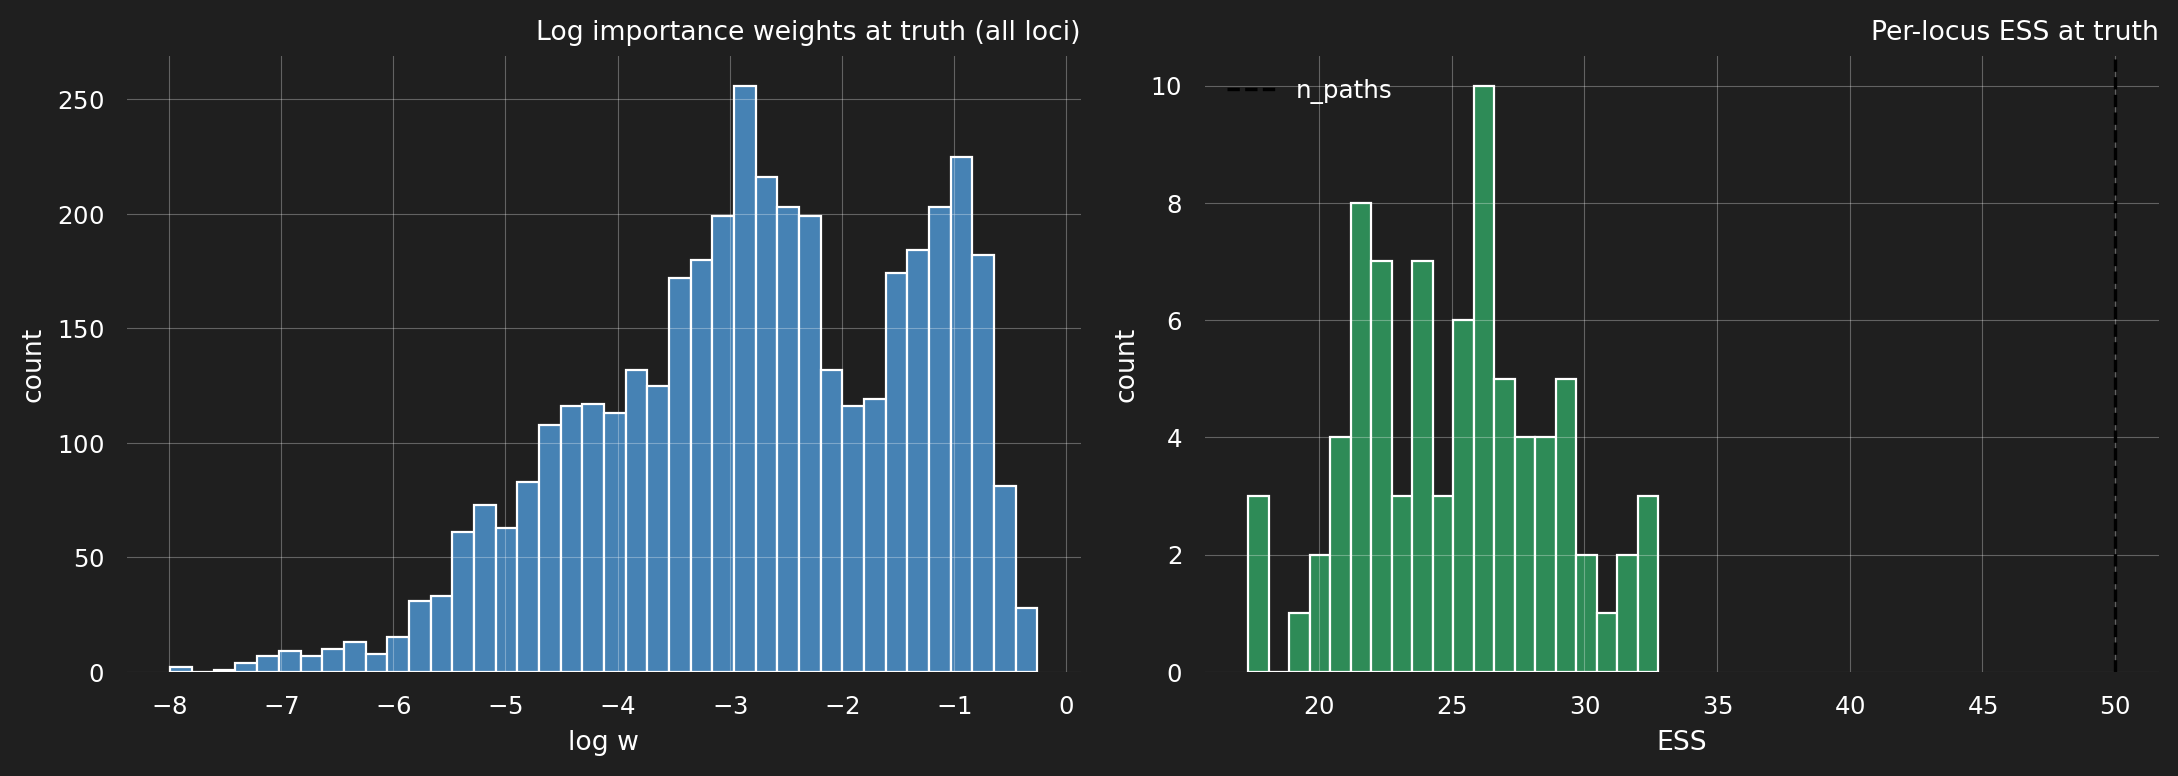

In [10]:
# Diagnostic 1: log-weight distributions and ESS at the true parameters
ll_true, diag = bffg_log_likelihood(true_theta, observed_data, n_paths=50, return_diagnostics=True)
print(f"BFFG log-likelihood at truth: {ll_true:.2f}")
all_log_w = np.concatenate(diag['log_weights_per_locus'])
ess = np.array(diag['ess_per_locus'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(all_log_w, bins=40, color='steelblue', edgecolor='white')
axes[0].set(xlabel='log w', ylabel='count', title='Log importance weights at truth (all loci)')
axes[1].hist(ess, bins=20, color='seagreen', edgecolor='white')
axes[1].axvline(50, color='k', ls='--', label='n_paths')
axes[1].set(xlabel='ESS', ylabel='count', title='Per-locus ESS at truth')
axes[1].legend()
plt.tight_layout(); plt.show()

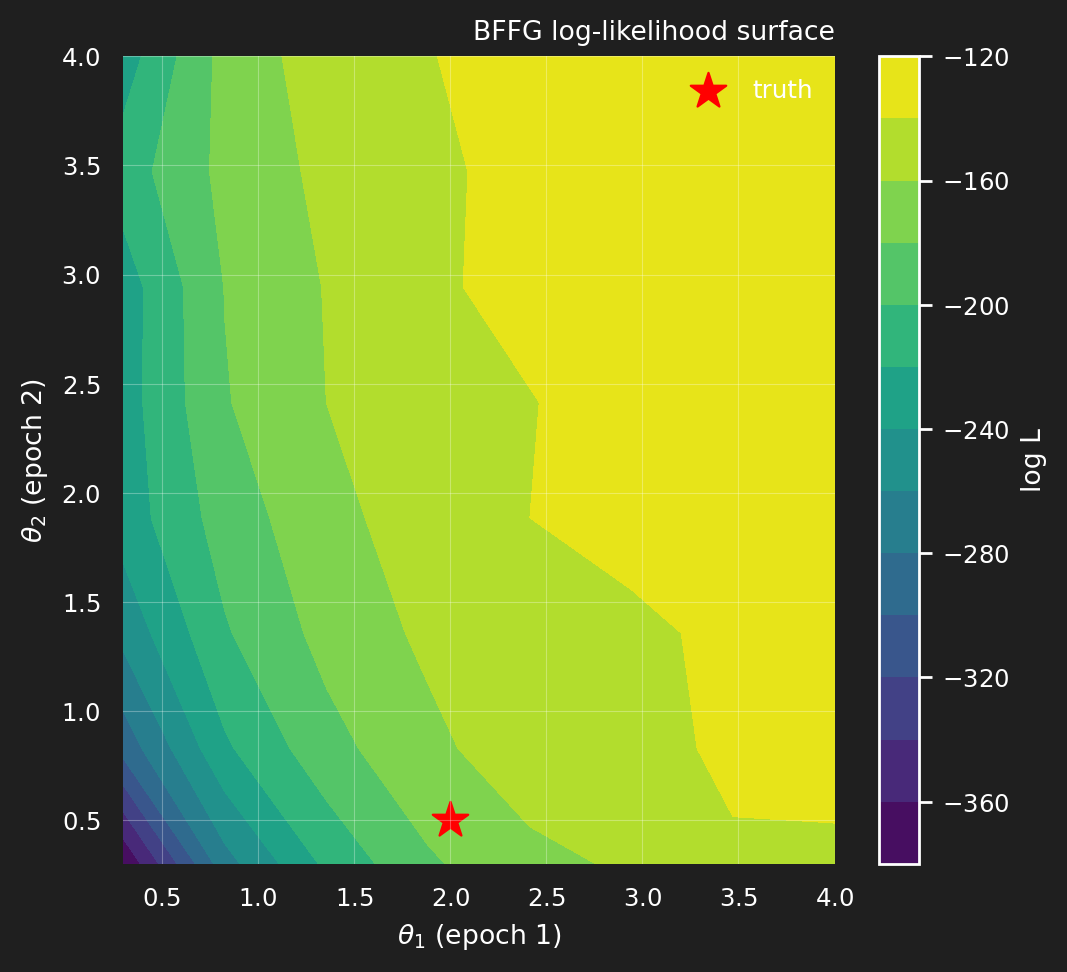

argmax: theta1=3.47, theta2=4.00
truth:  theta1=2.00, theta2=0.50


In [11]:
# Diagnostic 2: log-likelihood surface over (theta1, theta2)
grid = np.linspace(0.3, 4.0, 8)
Z = np.full((len(grid), len(grid)), np.nan)
for i, t1 in enumerate(grid):
    for j, t2 in enumerate(grid):
        Z[i, j] = bffg_log_likelihood(np.array([t1, t2]), observed_data, n_paths=20)

fig, ax = plt.subplots(figsize=(5.5, 5))
T1, T2 = np.meshgrid(grid, grid, indexing='ij')
im = ax.contourf(T1, T2, Z, levels=15, cmap='viridis')
ax.scatter([TRUE_THETA1], [TRUE_THETA2], color='red', marker='*', s=180, label='truth')
ax.set(xlabel=r'$\theta_1$ (epoch 1)', ylabel=r'$\theta_2$ (epoch 2)',
       title='BFFG log-likelihood surface')
plt.colorbar(im, ax=ax, label='log L')
ax.legend(); plt.tight_layout(); plt.show()

# argmax
i_max, j_max = np.unravel_index(np.argmax(Z), Z.shape)
print(f"argmax: theta1={grid[i_max]:.2f}, theta2={grid[j_max]:.2f}")
print(f"truth:  theta1={TRUE_THETA1:.2f}, theta2={TRUE_THETA2:.2f}")

## 8. MCMC inference

Plug the BFFG log-likelihood into `MCMC` via the `log_prob_fn` mode (the cleanest route — `bffg_log_prob` from the package implements the same idea but uses an exit-rate ratio instead of the event-density form, and is geared toward the FFI/JIT path).

In [12]:
def log_prob_fn(theta):
    return bffg_log_likelihood(theta, observed_data, n_paths=20)

mcmc = MCMC(
    log_prob_fn=log_prob_fn,
    prior=[GaussPrior(ci=[0.05, 8.0]), GaussPrior(ci=[0.05, 8.0])],
    theta_dim=2,
    n_samples=200,
    n_chains=2,
    burn_in=100,
    thin=1,
    proposal_scale=0.25,
    positive_params=True,
    jit=False,           # log_prob_fn calls back into Python/numpy
    seed=7,
    verbose=True,
    progress=True,
)
mcmc.run()
mcmc.summary()

  Chain 1: acceptance rate = 0.045
  Chain 2: acceptance rate = 0.020

MCMC complete!
Posterior mean: [5.08547773 5.08992416]
Posterior std:  [0.86165673 1.20906136]
R-hat:          [3.30420102 8.28838827]

MCMC Summary (2 chains, 200 samples/chain)
----------------------------------------------------------------------
Param          Mean        Std   HPD 2.5%  HPD 97.5%    R-hat      ESS
----------------------------------------------------------------------
theta[0]      5.0855     0.8617     3.6377     6.0032   3.3042      3.0
theta[1]      5.0899     1.2091     3.7439     6.5722   8.2884      2.7
----------------------------------------------------------------------
Acceptance rates: 0.045, 0.020


## 9. Posterior diagnostics

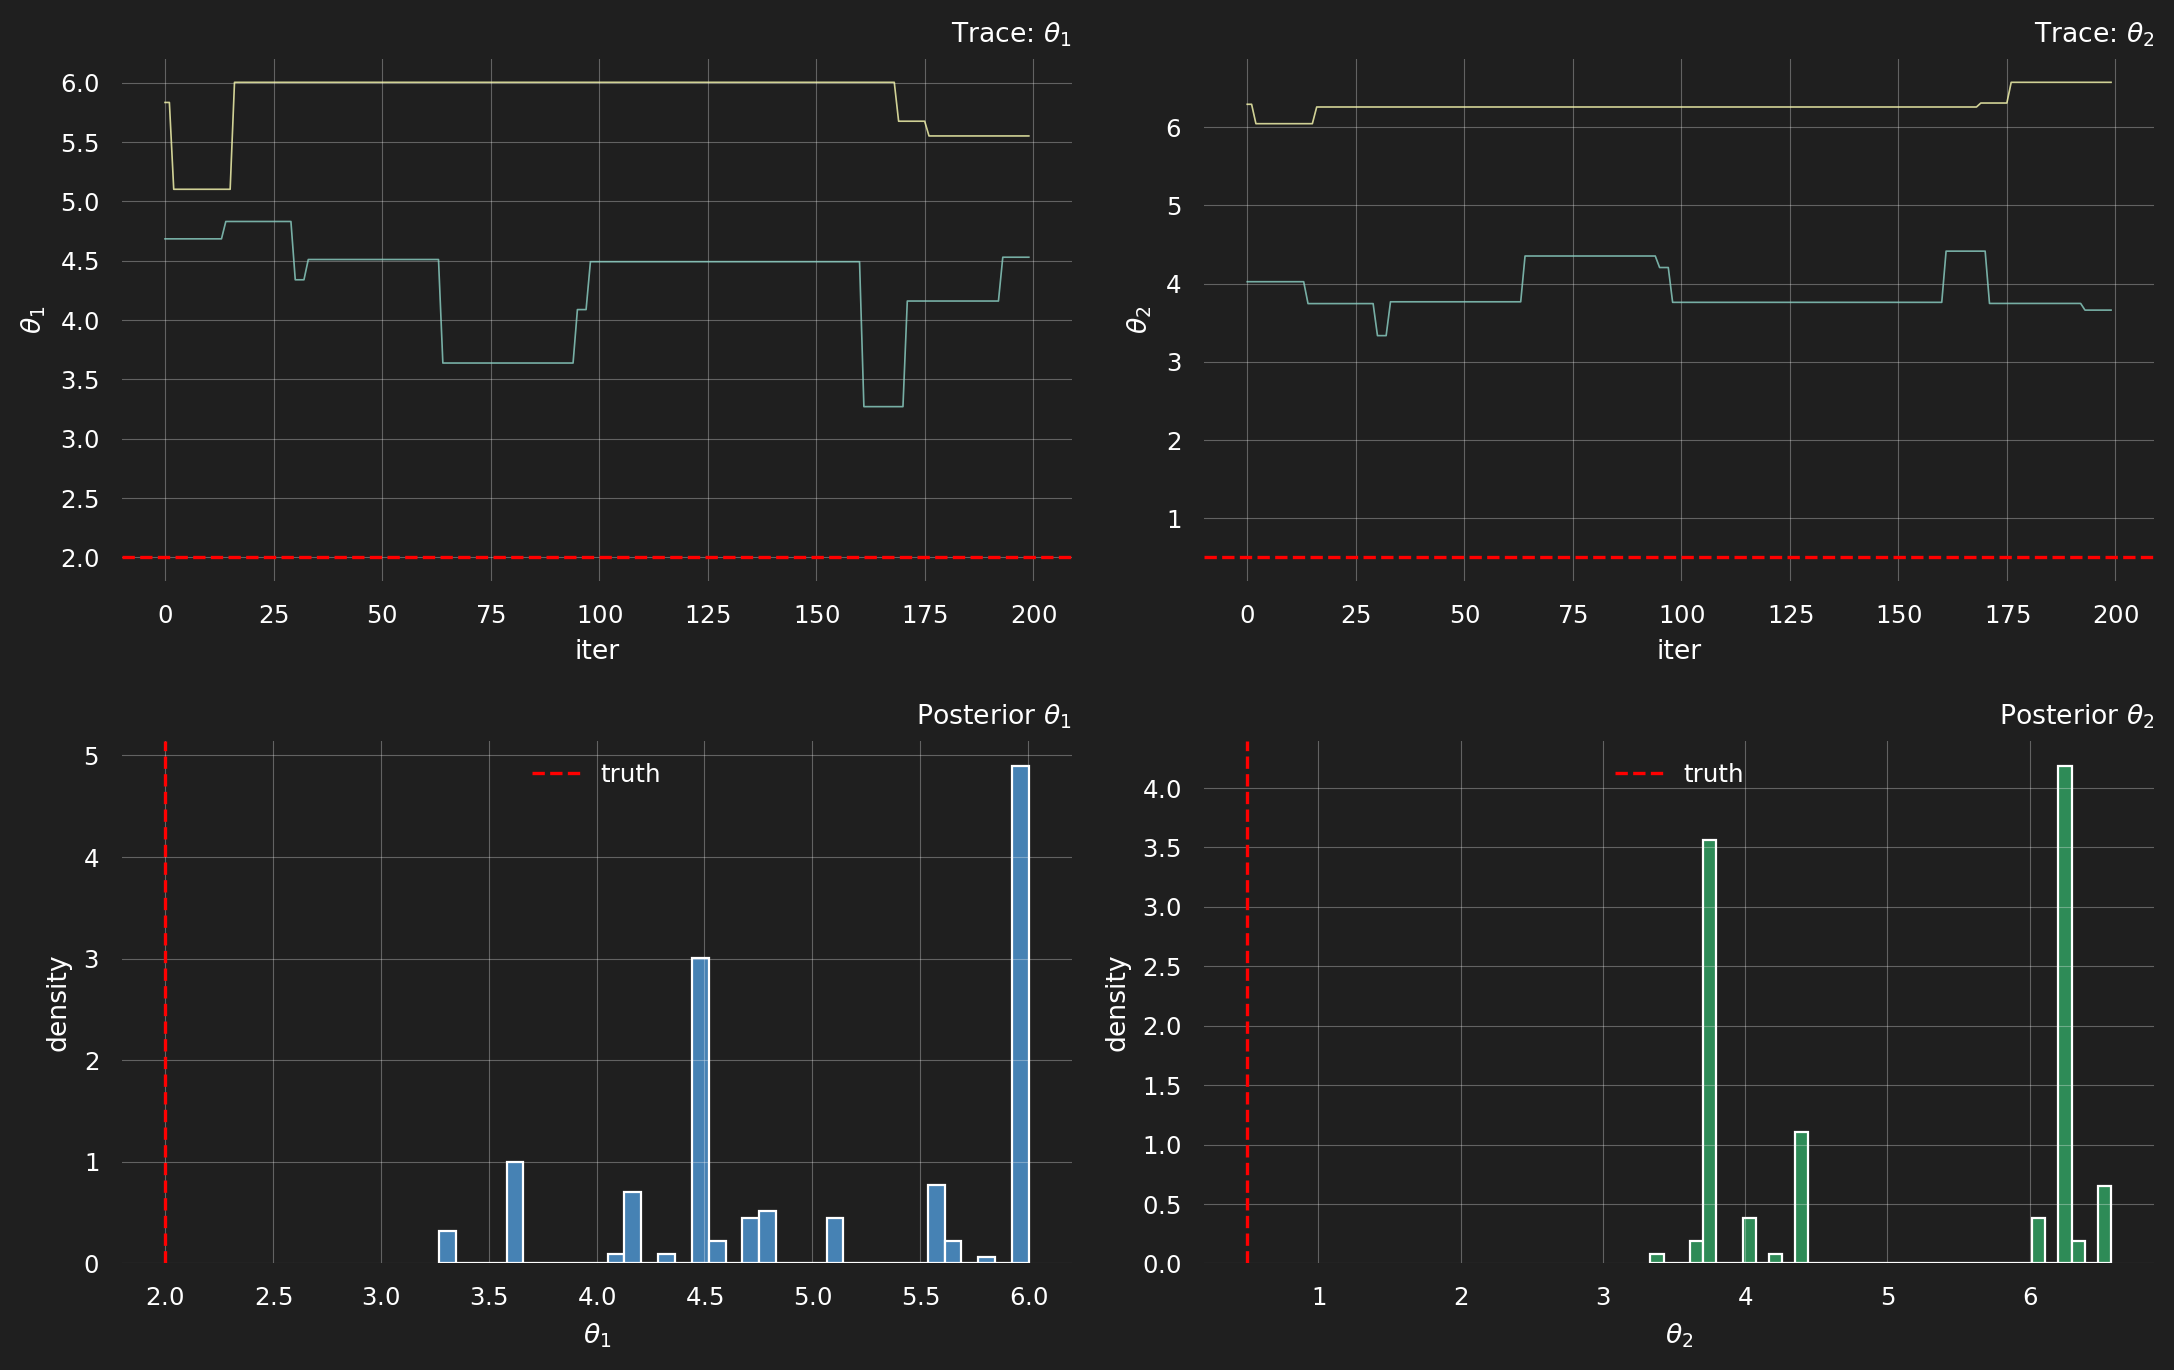

In [13]:
results = mcmc.get_results()
chains = results['chains']  # (n_chains, n_samples, 2)
samples = results['particles']  # (n_total, 2)

fig, axes = plt.subplots(2, 2, figsize=(11, 7))

# trace plots
for c in range(chains.shape[0]):
    axes[0, 0].plot(chains[c, :, 0], lw=0.6, alpha=0.8)
    axes[0, 1].plot(chains[c, :, 1], lw=0.6, alpha=0.8)
axes[0, 0].axhline(TRUE_THETA1, color='red', ls='--')
axes[0, 1].axhline(TRUE_THETA2, color='red', ls='--')
axes[0, 0].set(title=r'Trace: $\theta_1$', xlabel='iter', ylabel=r'$\theta_1$')
axes[0, 1].set(title=r'Trace: $\theta_2$', xlabel='iter', ylabel=r'$\theta_2$')

# marginal posteriors
axes[1, 0].hist(samples[:, 0], bins=35, color='steelblue', edgecolor='white', density=True)
axes[1, 0].axvline(TRUE_THETA1, color='red', ls='--', label='truth')
axes[1, 0].set(xlabel=r'$\theta_1$', ylabel='density', title=r'Posterior $\theta_1$')
axes[1, 0].legend()

axes[1, 1].hist(samples[:, 1], bins=35, color='seagreen', edgecolor='white', density=True)
axes[1, 1].axvline(TRUE_THETA2, color='red', ls='--', label='truth')
axes[1, 1].set(xlabel=r'$\theta_2$', ylabel='density', title=r'Posterior $\theta_2$')
axes[1, 1].legend()

plt.tight_layout(); plt.show()

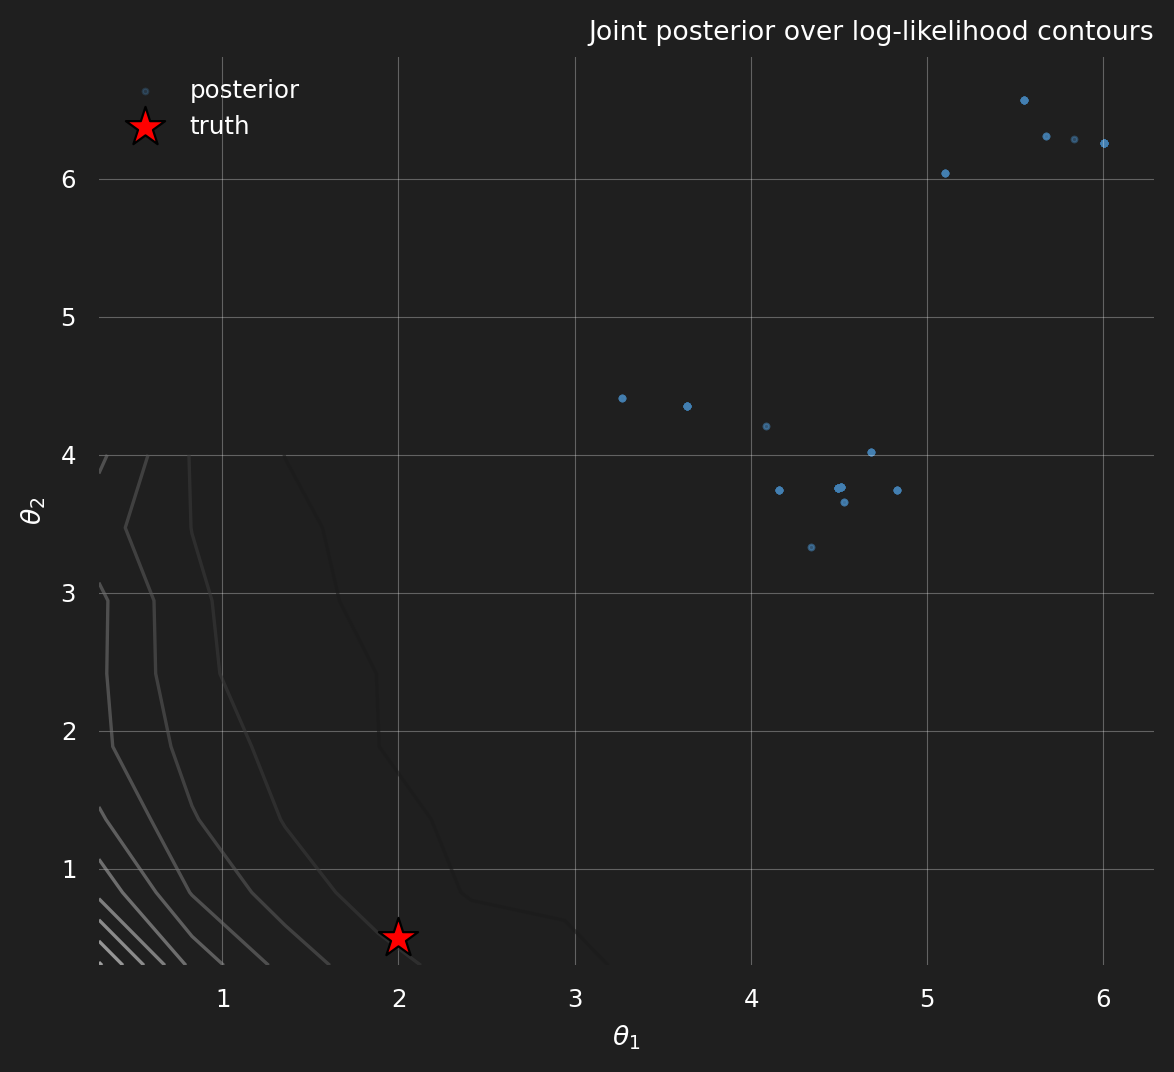

In [14]:
# joint posterior + log-likelihood contours
fig, ax = plt.subplots(figsize=(6, 5.5))
ax.contour(T1, T2, Z, levels=10, cmap='Greys', alpha=0.6)
ax.scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.25, color='steelblue', label='posterior')
ax.scatter([TRUE_THETA1], [TRUE_THETA2], color='red', marker='*', s=220,
           edgecolor='black', label='truth', zorder=5)
ax.set(xlabel=r'$\theta_1$', ylabel=r'$\theta_2$',
       title='Joint posterior over log-likelihood contours')
ax.legend(); plt.tight_layout(); plt.show()

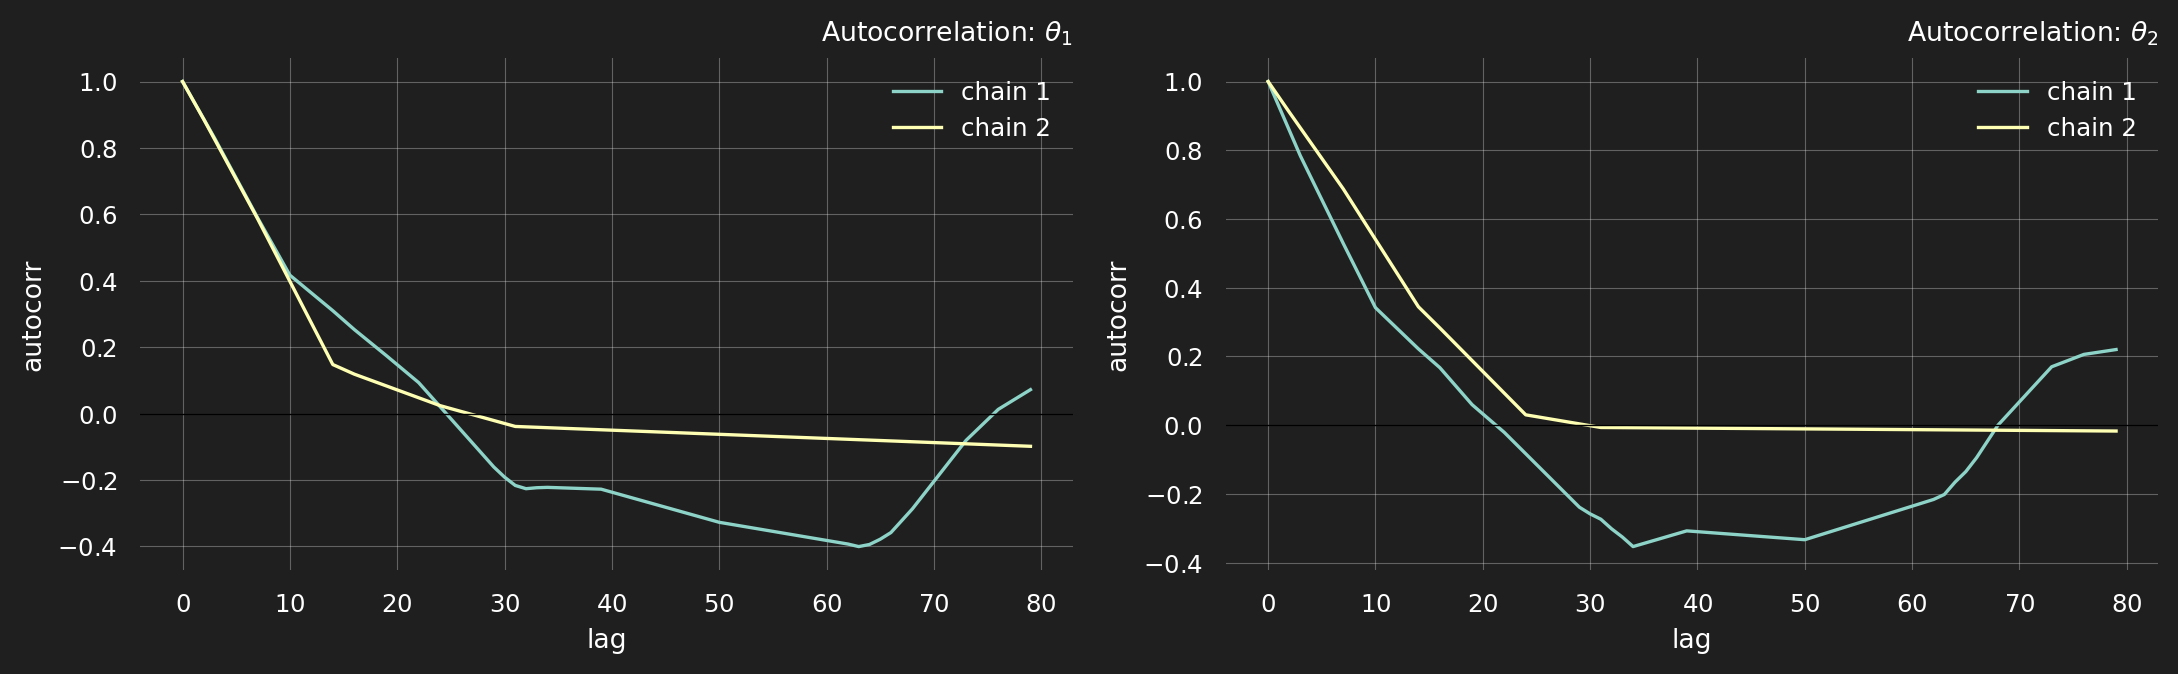

R-hat: [3.30420102 8.28838827]
ESS:   [2.9778034  2.73897887]


In [15]:
# Per-chain autocorrelation
from numpy.fft import fft, ifft

def autocorr(x, max_lag=80):
    x = x - x.mean()
    n = len(x)
    f = fft(x, n=2*n)
    acf = ifft(f * np.conj(f)).real[:max_lag] / (n * x.var())
    return acf

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for c in range(chains.shape[0]):
    axes[0].plot(autocorr(chains[c, :, 0]), label=f'chain {c+1}')
    axes[1].plot(autocorr(chains[c, :, 1]), label=f'chain {c+1}')
for ax, name in zip(axes, [r'$\theta_1$', r'$\theta_2$']):
    ax.axhline(0, color='k', lw=0.5)
    ax.set(xlabel='lag', ylabel='autocorr', title=f'Autocorrelation: {name}')
    ax.legend()
plt.tight_layout(); plt.show()

print('R-hat:', results.get('rhat'))
print('ESS:  ', results.get('ess'))

## 10. Compare with the package's `bffg_log_prob`

The library ships a ready-made BFFG inference helper that returns a JIT-compatible model term plus a stochastic correction. It uses a **different importance-weight formulation** than ours:

- **Manual (sections 4–9):** event-density form, exploiting the special structure of homogeneous coalescent proposal vs piecewise-constant target. Requires us to know that the model is a coalescent.
- **Package (`bffg_log_prob`):** generic exit-rate-ratio form,
$$
\log w = \sum_{\text{transient }v} \bigl[\log r^{\text{tgt}}_v - \log r^{\text{prop}}_v\bigr] - (r^{\text{tgt}}_v - r^{\text{prop}}_v)\,s_v + \log\frac{p^{\text{tgt}}_{v\to v'}}{p^{\text{prop}}_{v\to v'}}
$$
which works for any phase-type graph but evaluates `theta_target_fn` at every transient vertex along the path.

The two estimators target the same posterior but have different variance profiles. We run MCMC with the package version and overlay both posteriors.

In [16]:
from phasic import bffg_log_prob

# bffg_log_prob expects:
#   theta_proposal: GRAPH-level parameter vector (length = jg.param_length() = 2 here: [theta, mu])
#   theta_target_fn(theta_mcmc, t): returns a GRAPH-level vector of length param_length()
#       — the rate coefficient at time t plus the unchanged mutation rate.
#   theta_proposal_fn(theta_mcmc): JAX-traceable; returns the GRAPH-level vector used by
#       the model term (which is evaluated under the homogeneous proposal).

def theta_target_fn_pkg(theta_mcmc, t):
    """Graph-level theta vector at time t: [coalescence_rate(t), mutation_rate]."""
    rate = jnp.where(t < EPOCH_BOUNDARY, theta_mcmc[0], theta_mcmc[1])
    return jnp.array([rate, MUTATION_RATE])

def theta_proposal_fn_pkg(theta_mcmc):
    """Model term uses the homogeneous proposal regardless of theta_mcmc."""
    return jnp.array([THETA_0, MUTATION_RATE])

# Re-prime jg_disc to the proposal (joint_prob_table caching)
jg_disc.update_weights(theta_proposal.tolist())

model_pkg, correction_pkg = bffg_log_prob(
    jg_disc=jg_disc,
    jg_continuous=jg_cont,
    theta_proposal=theta_proposal,
    theta_target_fn=theta_target_fn_pkg,
    observed_data=observed_data,
    n_paths=20,
    theta_proposal_fn=theta_proposal_fn_pkg,
    return_model=True,
)

# Sanity check: evaluate at the truth
probs, _ = model_pkg(jnp.array(true_theta), jnp.array(observed_data, dtype=jnp.int32))
log_p_model_truth = float(jnp.sum(jnp.log(probs + 1e-30)))
log_corr_truth = float(correction_pkg(jnp.array(true_theta)))
print(f"Package BFFG at truth:  log P_model = {log_p_model_truth:.2f}, "
      f"log E[w] = {log_corr_truth:.2f}, total = {log_p_model_truth + log_corr_truth:.2f}")
print(f"Manual  BFFG at truth:  total = {ll_true:.2f}")

Package BFFG at truth:  log P_model = -94.12, log E[w] = 50.41, total = -43.71
Manual  BFFG at truth:  total = -170.67


In [17]:
# Run MCMC using the package's (model, likelihood_correction) split.
# The model term uses the FFI trace cache (JIT-compatible), the correction
# uses sampled paths (non-JIT). MCMC.likelihood_correction adds the
# correction outside the JIT'd model evaluation.

mcmc_pkg = MCMC(
    model=model_pkg,
    observed_data=jnp.array(observed_data, dtype=jnp.int32),
    likelihood_correction=correction_pkg,
    prior=[GaussPrior(ci=[0.05, 8.0]), GaussPrior(ci=[0.05, 8.0])],
    theta_dim=2,
    n_samples=400,
    n_chains=2,
    burn_in=200,
    thin=1,
    proposal_scale=0.25,
    positive_params=True,
    jit=True,             # the model term jits; correction stays in Python
    seed=7,
    verbose=True,
    progress=True,
)
mcmc_pkg.run()
mcmc_pkg.summary()

  Chain 1: acceptance rate = 0.350
  Chain 2: acceptance rate = 0.350

MCMC complete!
Posterior mean: [4.58508861 4.79068686]
Posterior std:  [0.44783681 1.75335439]
R-hat:          [1.05968663 0.99938055]

MCMC Summary (2 chains, 400 samples/chain)
----------------------------------------------------------------------
Param          Mean        Std   HPD 2.5%  HPD 97.5%    R-hat      ESS
----------------------------------------------------------------------
theta[0]      4.5851     0.4478     3.7055     5.3542   1.0597     91.3
theta[1]      4.7907     1.7534     1.8328     7.9924   0.9994    127.3
----------------------------------------------------------------------
Acceptance rates: 0.350, 0.350


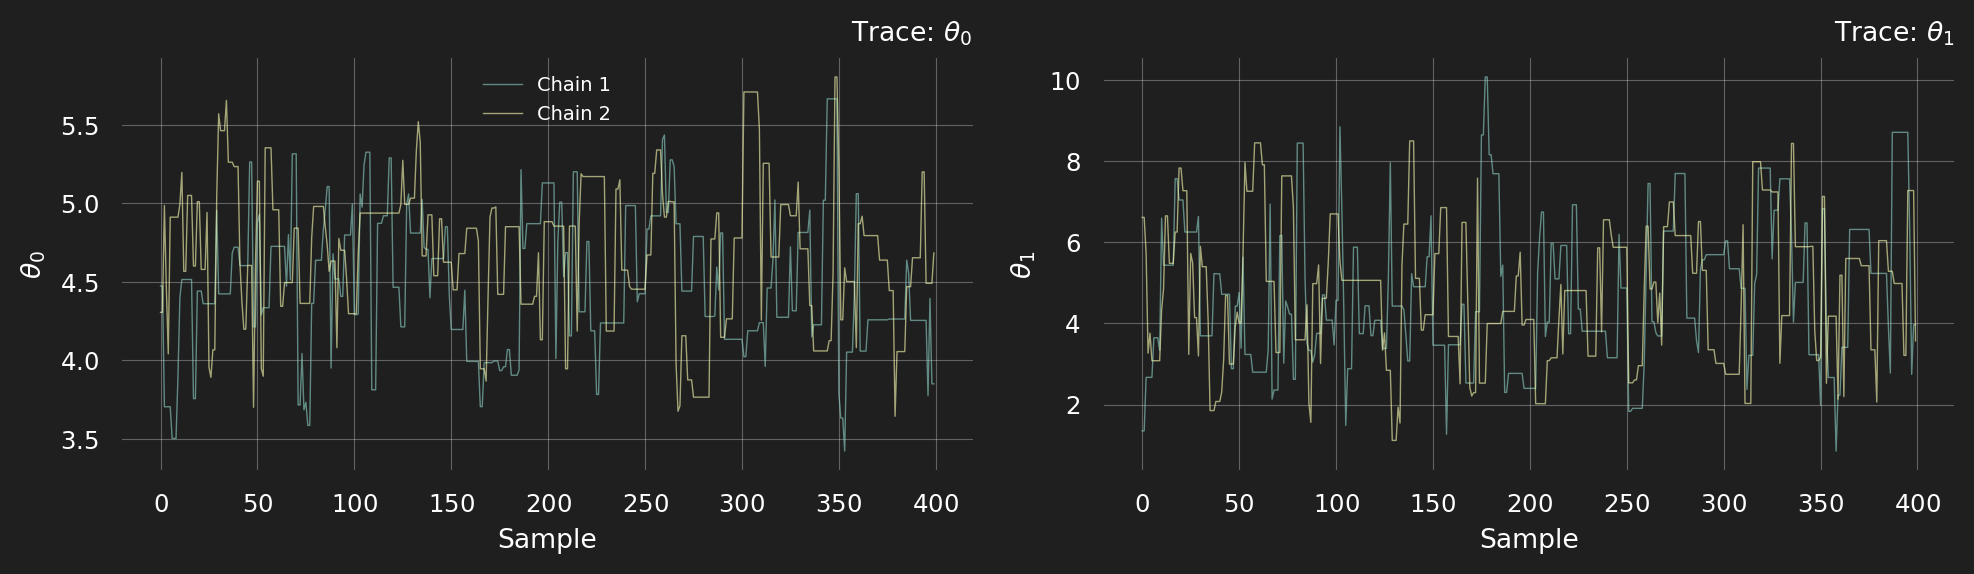

In [22]:
mcmc_pkg.plot_chains()

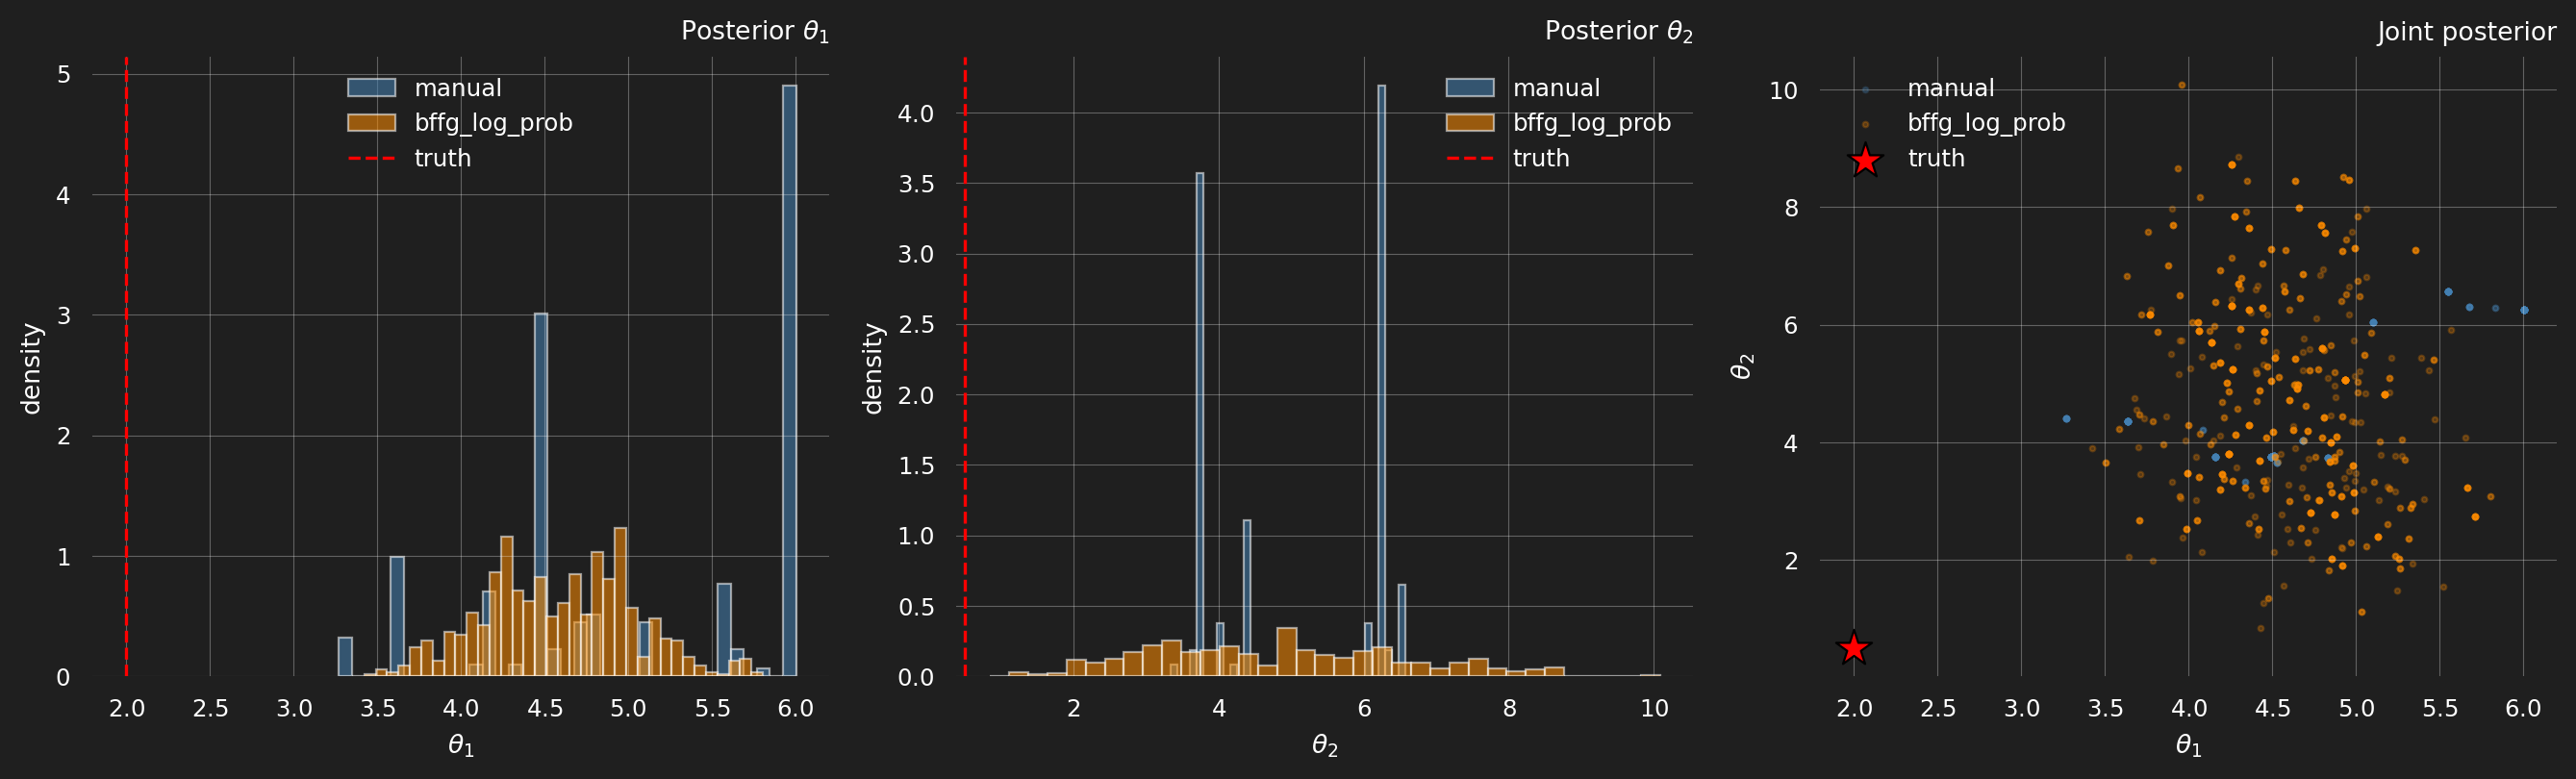

Posterior means:
  manual:        theta1 = 5.085, theta2 = 5.090
  bffg_log_prob: theta1 = 4.585, theta2 = 4.791
  truth:         theta1 = 2.0, theta2 = 0.5


In [18]:
# Overlay the two posteriors
results_pkg = mcmc_pkg.get_results()
samples_pkg = results_pkg['particles']
chains_pkg = results_pkg['chains']

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

# Marginal: theta1
axes[0].hist(samples[:, 0], bins=35, density=True, alpha=0.55,
             color='steelblue', edgecolor='white', label='manual')
axes[0].hist(samples_pkg[:, 0], bins=35, density=True, alpha=0.55,
             color='darkorange', edgecolor='white', label='bffg_log_prob')
axes[0].axvline(TRUE_THETA1, color='red', ls='--', label='truth')
axes[0].set(xlabel=r'$\theta_1$', ylabel='density', title=r'Posterior $\theta_1$')
axes[0].legend()

# Marginal: theta2
axes[1].hist(samples[:, 1], bins=35, density=True, alpha=0.55,
             color='steelblue', edgecolor='white', label='manual')
axes[1].hist(samples_pkg[:, 1], bins=35, density=True, alpha=0.55,
             color='darkorange', edgecolor='white', label='bffg_log_prob')
axes[1].axvline(TRUE_THETA2, color='red', ls='--', label='truth')
axes[1].set(xlabel=r'$\theta_2$', ylabel='density', title=r'Posterior $\theta_2$')
axes[1].legend()

# Joint scatter
axes[2].scatter(samples[:, 0], samples[:, 1], s=4, alpha=0.25,
                color='steelblue', label='manual')
axes[2].scatter(samples_pkg[:, 0], samples_pkg[:, 1], s=4, alpha=0.25,
                color='darkorange', label='bffg_log_prob')
axes[2].scatter([TRUE_THETA1], [TRUE_THETA2], color='red', marker='*', s=200,
                edgecolor='black', zorder=5, label='truth')
axes[2].set(xlabel=r'$\theta_1$', ylabel=r'$\theta_2$', title='Joint posterior')
axes[2].legend()

plt.tight_layout(); plt.show()

print("Posterior means:")
print(f"  manual:        theta1 = {results['theta_mean'][0]:.3f}, "
      f"theta2 = {results['theta_mean'][1]:.3f}")
print(f"  bffg_log_prob: theta1 = {results_pkg['theta_mean'][0]:.3f}, "
      f"theta2 = {results_pkg['theta_mean'][1]:.3f}")
print(f"  truth:         theta1 = {TRUE_THETA1}, theta2 = {TRUE_THETA2}")

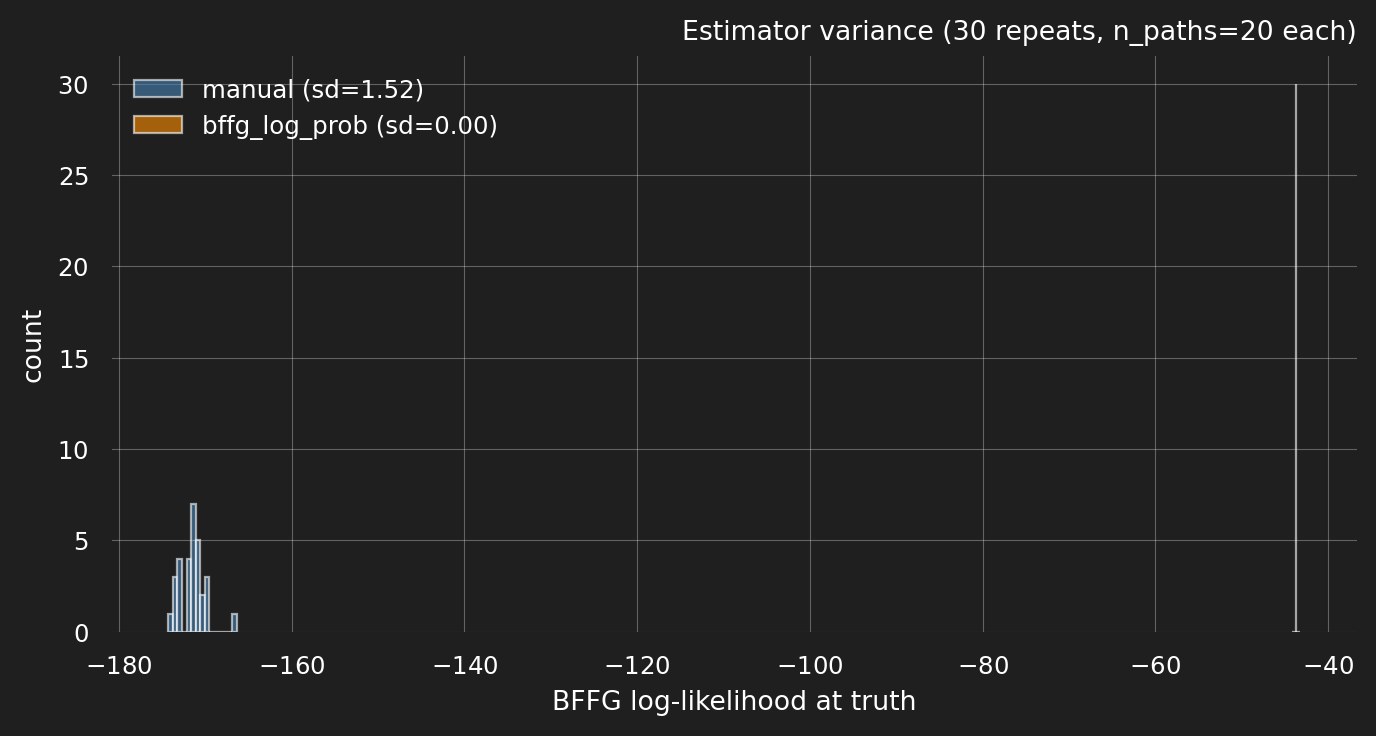

Manual:        mean = -171.48, sd = 1.52
bffg_log_prob: mean = -43.71, sd = 0.00


In [19]:
# Per-evaluation comparison: stack repeated log-likelihood evaluations at the truth
# to compare estimator variance between the two BFFG implementations.
n_repeats = 30

ll_manual = np.array([
    bffg_log_likelihood(true_theta, observed_data, n_paths=20)
    for _ in range(n_repeats)
])

# Package version: model is deterministic given theta, correction is stochastic
probs_truth, _ = model_pkg(jnp.array(true_theta), jnp.array(observed_data, dtype=jnp.int32))
log_p_model = float(jnp.sum(jnp.log(probs_truth + 1e-30)))
ll_pkg = np.array([
    log_p_model + float(correction_pkg(jnp.array(true_theta)))
    for _ in range(n_repeats)
])

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(ll_manual, bins=15, alpha=0.6, color='steelblue', edgecolor='white',
        label=f'manual (sd={ll_manual.std():.2f})')
ax.hist(ll_pkg, bins=15, alpha=0.6, color='darkorange', edgecolor='white',
        label=f'bffg_log_prob (sd={ll_pkg.std():.2f})')
ax.set(xlabel='BFFG log-likelihood at truth', ylabel='count',
       title=f'Estimator variance ({n_repeats} repeats, n_paths=20 each)')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Manual:        mean = {ll_manual.mean():.2f}, sd = {ll_manual.std():.2f}")
print(f"bffg_log_prob: mean = {ll_pkg.mean():.2f}, sd = {ll_pkg.std():.2f}")

## 11. Posterior predictive check

Draw a posterior parameter sample, simulate fresh observations under it, compare the implied SFS counts to those observed.

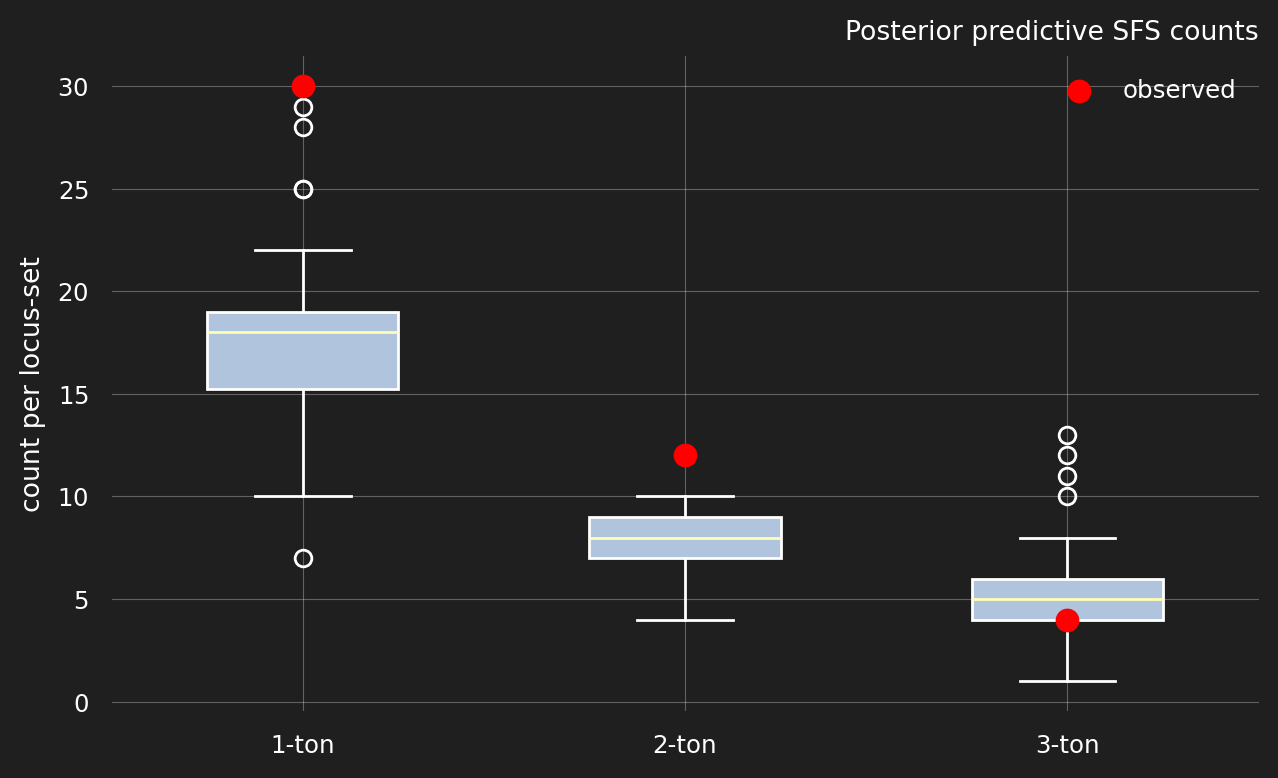

In [20]:
n_pred = 30
pred_counts = np.zeros((n_pred, N_SAMPLES - 1), dtype=int)
post_idx = rng.choice(samples.shape[0], size=n_pred, replace=False)
pred_rng = np.random.default_rng(401)
for k, idx in enumerate(post_idx):
    th = np.asarray(samples[idx])
    for _ in range(N_LOCI):
        try:
            term = simulate_observation(
                th, MUTATION_RATE, EPOCH_BOUNDARY, v_start_idx, edge_cache_cont,
                valid_t_vertices, trash_vertices, pred_rng,
            )
            j = term_to_type.get(term)
            if j is not None:
                pred_counts[k, j - 1] += 1
        except RuntimeError:
            continue

fig, ax = plt.subplots(figsize=(6.5, 4))
x = np.arange(N_SAMPLES - 1)
ax.boxplot([pred_counts[:, j] for j in x], positions=x, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue'))
ax.scatter(x, mut_type_counts, color='red', zorder=5, label='observed', s=60)
ax.set_xticks(x)
ax.set_xticklabels([f'{j+1}-ton' for j in x])
ax.set(ylabel='count per locus-set', title='Posterior predictive SFS counts')
ax.legend(); plt.tight_layout(); plt.show()